## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Fri Mar 21 12:21:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

⚠️ YOLOv8 is still under heavy development. Breaking changes are being introduced almost weekly. We strive to make our YOLOv8 notebooks work with the latest version of the library. Last tests took place on **18.01.2023** with version **YOLOv8.0.9**.

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.2/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

## CLI Basics

## Inference with Pre-trained COCO Model

### 💻 CLI

`yolo mode=predict` runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to `runs/predict`.

In [ ]:
%cd {HOME}
!yolo task=segment mode=predict model=yolov8s-seg.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg'

/content
100% 22.8M/22.8M [00:00<00:00, 410MB/s]
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 420, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/engine/model.py", line 97, in __init__
    self._load(model, task)
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/engine/model.py", line 149, in _load
    self.model, self.ckpt = attempt_load_one_weight(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py", line 628, in attempt_load_one_weight
    ckpt, weight = torch_safe_load(weight)  # load ckpt
                   ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py", line 567, i

In [ ]:
%cd {HOME}
Image(filename='runs/segment/predict/dog.jpeg', height=600)

/content


FileNotFoundError: [Errno 2] No such file or directory: 'runs/segment/predict/dog.jpeg'

### 🐍 Python SDK

The simplest way of simply using YOLOv8 directly in a Python environment.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="yqJYScDx5PznoKvd2NBP")
project = rf.workspace("freedomtech").project("rpi4-yolov8-segmentation")
dataset = project.version(1).download("yolov8")

mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...


RoboflowError: {
    "error": {
        "message": "Unsupported request. `GET /freedomtech/rpi4-yolov8-segmentation` does not exist or cannot be loaded due to missing permissions.",
        "type": "GraphMethodException",
        "hint": "You can see your active workspace by issuing a GET request to `/` with your `api_key`."
    }
}

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=segment mode=train model=yolov8s-seg.pt data={dataset.location}/data.yaml epochs=100 imgsz=640

In [ ]:
!pip install cvzone

  Preparing metadata (setup.py) ... done
  Created wheel for cvzone: filename=cvzone-1.6.1-py3-none-any.whl size=26298 sha256=f2ae13c502120c238a89fd69ca916493bfa39da6594d41696409de8b7501dcb7
  Stored in directory: /root/.cache/pip/wheels/ab/36/ec/47be2d4e59dc4289e684d5b0dde54d1e72e51a614e57690e85
Successfully built cvzone


In [ ]:
!pip install torch==2.5.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.7/174.7 MB 5.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 53.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.1 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0+cu124
    Uninstalling torch-2.6.0+cu124:
      Successfully uninstalled torch-2.6.0+cu124
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.2


0: 320x640 5 roadpotholes, 246.8ms
Speed: 2.6ms preprocess, 246.8ms inference, 8.2ms postprocess per image at shape (1, 3, 320, 640)


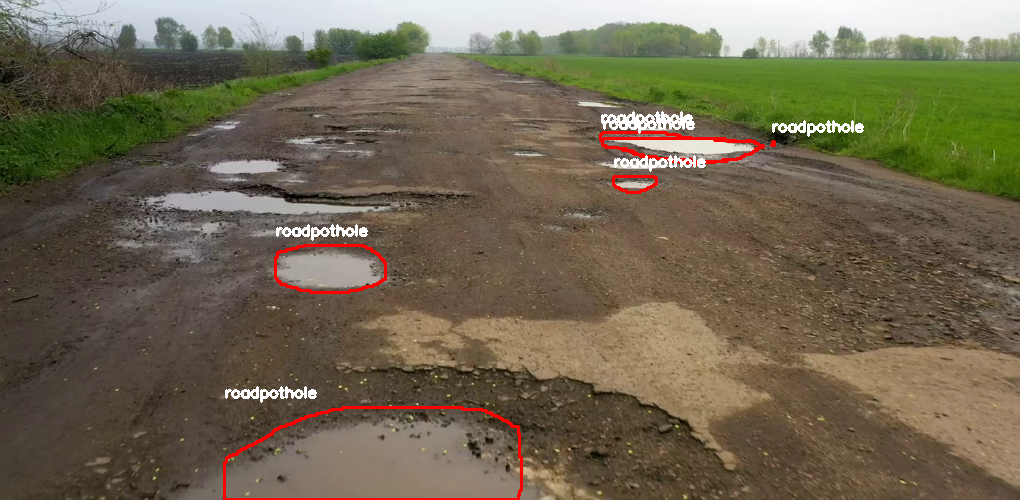

error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1367: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvWaitKey'


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import cvzone
from google.colab.patches import cv2_imshow

# Load a model
model = YOLO("best.pt")
class_names = model.names
cap = cv2.VideoCapture('p.mp4')
count = 0

while True:
    ret, img = cap.read()
    if not ret:
        break
    count += 1
    if count % 3 != 0:
        continue

    img = cv2.resize(img, (1020, 500))
    h, w, _ = img.shape
    results = model.predict(img)

    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs

    if masks is not None:
        masks = masks.data.cpu()
        for seg, box in zip(masks.data.cpu().numpy(), boxes):
            seg = cv2.resize(seg, (w, h))
            contours, _ = cv2.findContours((seg).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for contour in contours:
                d = int(box.cls)
                c = class_names[d]
                x, y,x1,y1 = cv2.boundingRect(contour)
                cv2.polylines(img, [contour],True, color=(0, 0, 255), thickness=2)
#                cv2.rectangle(img,(x,y),(x1+x,y1+y),(255,0,0),2)
                cv2.putText(img, c, (x,y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    cv2_imshow(img)
    if cv2.waitKey(0) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
!pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 13.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import supervision as sv
from tqdm import tqdm
import os

# Load a model
model = YOLO("best.pt")
class_names = model.names

# Create output directory if it doesn't exist
os.makedirs('/content', exist_ok=True)

# Video input and output setup
cap = cv2.VideoCapture('p.mp4')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = 1020
height = 500
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Create video writer
output_path = '/content/output_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Frame generator with tqdm for progress tracking
def frame_generator():
    count = 0
    with tqdm(total=total_frames) as pbar:
        while True:
            ret, img = cap.read()
            if not ret:
                break
            count += 1
            pbar.update(1)

            # Process every 3rd frame
            if count % 3 != 0:
                continue

            img = cv2.resize(img, (width, height))
            yield count, img

# Annotator for drawing
mask_annotator = sv.MaskAnnotator(color=sv.ColorPalette.DEFAULT)
box_annotator = sv.BoxAnnotator(color=sv.ColorPalette.DEFAULT, thickness=2)
text_annotator = sv.LabelAnnotator()

# Process frames
for _, frame in frame_generator():
    # Run inference
    results = model.predict(frame)

    for r in results:
        boxes = r.boxes
        masks = r.masks

        if masks is not None:
            masks = masks.data.cpu().numpy()
            h, w, _ = frame.shape

            for i, (mask, box) in enumerate(zip(masks, boxes)):
                # Resize mask to frame dimensions
                mask = cv2.resize(mask, (w, h))

                # Get class information
                class_id = int(box.cls)
                class_name = class_names[class_id]

                # Find contours
                contours, _ = cv2.findContours(
                    mask.astype(np.uint8),
                    cv2.RETR_EXTERNAL,
                    cv2.CHAIN_APPROX_SIMPLE
                )

                # Draw contours
                cv2.polylines(
                    frame,
                    contours,
                    True,
                    color=(0, 0, 255),
                    thickness=2
                )

                if len(contours) > 0:
                    # Draw contours
                    cv2.polylines(
                        frame,
                        contours,
                        True,
                        color=(0, 0, 255),
                        thickness=2
                    )

                    # Add label
                    x, y, w, h = cv2.boundingRect(contours[0])
                    cv2.putText(
                        frame,
                        class_name,
                        (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 255, 255),
                        2
                    )
                else:
                    # If no contours found, use the bounding box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(
                        frame,
                        class_name,
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 255, 255),
                        2
                    )

    # Write frame to output video
    video_writer.write(frame)

# Release resources
cap.release()
video_writer.release()
cv2.destroyAllWindows()

print(f"Video processing complete. Output saved to {output_path}")

  0%|          | 0/692 [00:00<?, ?it/s]
0: 320x640 5 roadpotholes, 276.1ms
Speed: 4.6ms preprocess, 276.1ms inference, 8.7ms postprocess per image at shape (1, 3, 320, 640)
  1%|          | 4/692 [00:01<04:48,  2.38it/s]
0: 320x640 5 roadpotholes, 283.6ms
Speed: 2.6ms preprocess, 283.6ms inference, 8.4ms postprocess per image at shape (1, 3, 320, 640)
  1%|          | 7/692 [00:02<02:57,  3.86it/s]
0: 320x640 5 roadpotholes, 260.6ms
Speed: 2.8ms preprocess, 260.6ms inference, 10.3ms postprocess per image at shape (1, 3, 320, 640)
  1%|▏         | 10/692 [00:02<02:11,  5.21it/s]
0: 320x640 6 roadpotholes, 276.8ms
Speed: 2.5ms preprocess, 276.8ms inference, 12.5ms postprocess per image at shape (1, 3, 320, 640)
  2%|▏         | 13/692 [00:02<01:49,  6.23it/s]
0: 320x640 6 roadpotholes, 278.9ms
Speed: 3.0ms preprocess, 278.9ms inference, 10.0ms postprocess per image at shape (1, 3, 320, 640)
  2%|▏         | 16/692 [00:02<01:35,  7.06it/s]
0: 320x640 6 roadpotholes, 258.5ms
Speed: 2.5ms p

error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
